In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
lat_min, lat_max = 45, 49
lon_min, lon_max = -109, -100
year = 2017

In [3]:
## Direct download from the FLASH https://vadosezone.tamu.edu/flash/
## Links to a google drive, download locally size about 5GB (2015 - 2019)

In [4]:
ds = xr.open_dataset("FDSI.nc", decode_times=False)

time_vals = ds["Time"].values.astype(str)
time_parsed = pd.to_datetime(time_vals, format="%Y%m%d", errors="coerce")

ds = ds.assign_coords(Time=time_parsed)

In [5]:
ds

<xarray.Dataset> Size: 5GB
Dimensions:    (Time: 3071, Latitude: 447, Longitude: 946)
Coordinates:
  * Longitude  (Longitude) float64 8kB -179.8 -179.4 -179.0 ... 179.1 179.5
  * Latitude   (Latitude) float64 4kB 84.85 84.47 84.09 ... -84.15 -84.53 -84.91
  * Time       (Time) datetime64[ns] 25kB 2015-03-31 2015-04-01 ... 2024-01-03
Data variables:
    crs        int32 4B ...
    FDSI       (Time, Latitude, Longitude) float32 5GB ...
Attributes:
    Conventions:  CF-1.4
    created_by:   R, packages ncdf4 and raster (version 3.6-26)
    date:         2024-01-05 11:18:15

In [6]:


ds_2017 = ds.sel(Time=slice('2017-01-01','2017-12-31'), Latitude=slice(lat_max, lat_min), Longitude = slice(lon_min, lon_max))

ds_2017

<xarray.Dataset> Size: 339kB
Dimensions:    (Time: 365, Latitude: 10, Longitude: 23)
Coordinates:
  * Longitude  (Longitude) float64 184B -108.7 -108.3 -107.9 ... -100.7 -100.3
  * Latitude   (Latitude) float64 80B 48.69 48.31 47.93 ... 46.03 45.65 45.27
  * Time       (Time) datetime64[ns] 3kB 2017-01-01 2017-01-02 ... 2017-12-31
Data variables:
    crs        int32 4B ...
    FDSI       (Time, Latitude, Longitude) float32 336kB ...
Attributes:
    Conventions:  CF-1.4
    created_by:   R, packages ncdf4 and raster (version 3.6-26)
    date:         2024-01-05 11:18:15

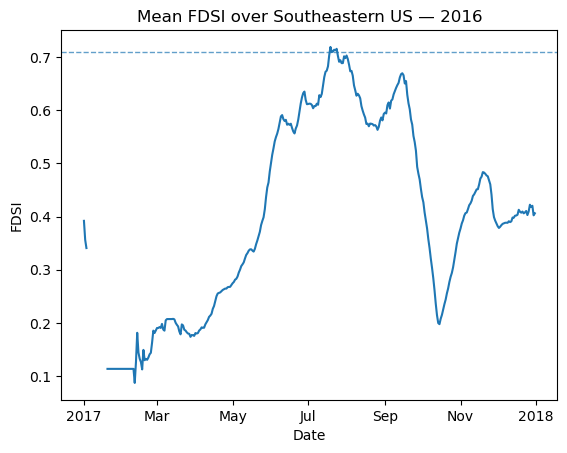

In [7]:
fdsi_mean = ds_2017['FDSI'].mean(dim=['Latitude', 'Longitude'])
fdsi_mean.plot.line()
plt.axhline(0.71, linestyle='--', linewidth=1, alpha=0.7, label='FDSI = 0.71')
plt.title("Mean FDSI over Northern Plains US — 2017")
plt.xlabel("Date")
plt.ylabel("FDSI")
plt.show()


In [8]:
# 14-day and 28 rolling mean to smooth 
fdsi_roll_14 = ds['FDSI'].rolling(Time=14).mean()
fdsi_roll_28 = ds['FDSI'].rolling(Time=28,).mean()

#subset for the region and timeframe for 2017
region_14 = fdsi_roll_14.sel(Time=slice('2017-01-01','2017-12-31'), Latitude=slice(lat_max, lat_min), Longitude = slice(lon_min, lon_max))
region_28 = fdsi_roll_28.sel(Time=slice('2017-01-01','2017-12-31'), Latitude=slice(lat_max, lat_min), Longitude = slice(lon_min, lon_max))



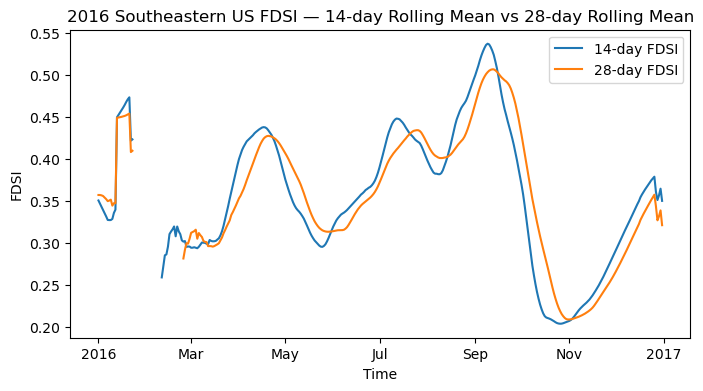

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

region_14.mean(dim=['Latitude','Longitude']).plot(ax=ax, label='14-day FDSI')
region_28.mean(dim=['Latitude','Longitude']).plot(ax=ax, label='28-day FDSI')
ax.set_title("2017 Southeastern US FDSI — 14-day Rolling Mean vs 28-day Rolling Mean")
ax.set_xlabel("Time")
ax.set_ylabel("FDSI")
ax.legend()

plt.show()


In [29]:
ts = region_14.mean(dim=["Latitude", "Longitude"], skipna=True)

lowest_time = ts['Time'][ts.argmin().item()]
highest_time = ts['Time'][ts.argmax().item()]

region_lowest  = region_14.sel(Time=lowest_time)
region_highest = region_14.sel(Time=highest_time)


In [30]:

ts_window = ts.sel(Time=slice(lowest_time, highest_time))
delta_val = ts_window.sel(Time=highest_time) - ts_window.sel(Time=lowest_time)


delta_days = (highest_time.values - lowest_time.values) / np.timedelta64(1, "D")
weekly_rate_avg = delta_val / (delta_days / 7)


ts_window = ts.sel(Time=slice(lowest_time, highest_time))
dval = ts_window.diff("Time")
dt_days = ts_window["Time"].diff("Time") / np.timedelta64(1, "D")
weekly_rate_series = (dval / dt_days) * 7
weekly_rate_series = weekly_rate_series.assign_coords(
    Time=ts_window["Time"][1:]
)


###########2 week rate ############################

rate_avg_14 = delta_val / (delta_days / 14)

rate_series_14 = (dval / dt_days) * 14 # rate per week for each step

# give the rates the "later" timestamps
rate_series_14 = rate_series_14.assign_coords(
    Time=ts_window["Time"][1:]
)

###########4 week


rate_avg_28 = delta_val / (delta_days / 28)
rate_series_28 = (dval / dt_days) * 28

rate_series_28 = rate_series_28.assign_coords(
    Time=ts_window["Time"][1:]
)


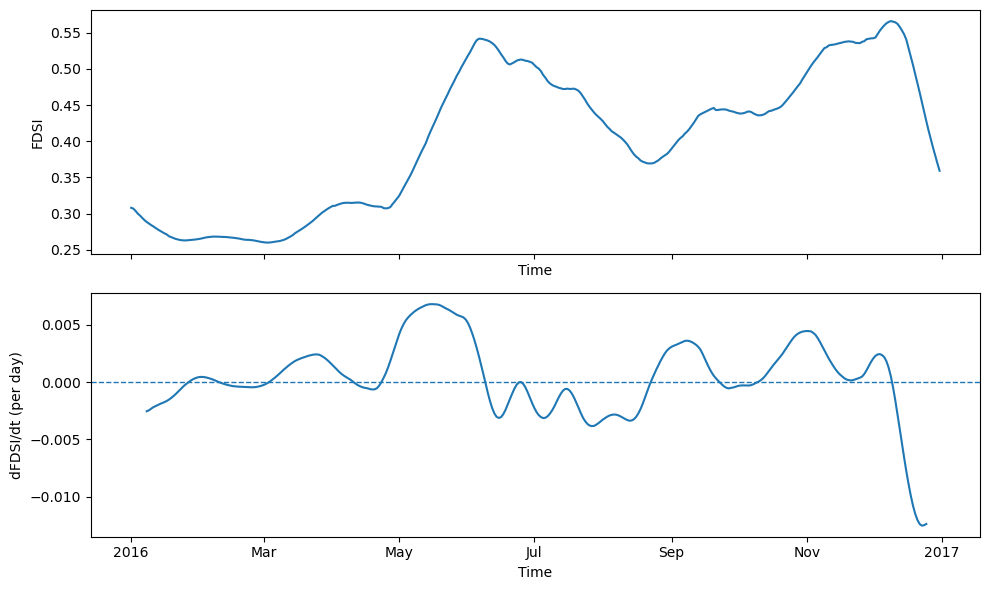

In [31]:
## Measure the rate of change for the FDSI that accounts for the acceleration 
## Notable fluctuations
#

ts = region_14.mean(dim=["Latitude", "Longitude"], skipna=True)

# numeric time in days
t = (ts["Time"] - ts["Time"][0]) / np.timedelta64(1, 'D')
t = xr.DataArray(t, coords=[ts["Time"]], dims=["Time"])

def slope(x, y):
    if np.any(np.isnan(y)):
        return np.nan
    coef = np.polyfit(x, y, 1)
    return coef[0]  # slope per day

rolling_slope_14 = xr.apply_ufunc(
    slope,
    t.rolling(Time=14, center=True).construct("window"),
    ts.rolling(Time=14, center=True).construct("window"),
    input_core_dims=[["window"], ["window"]],
    vectorize=True,
    dask="parallelized",
)

rolling_slope_14 


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,6), sharex=True)

# FDSI
ts.plot(ax=ax1)
ax1.set_ylabel("FDSI")
ax1.set_xlabel("Time")

# rolling slope
rolling_slope_14.plot(ax=ax2)
ax2.axhline(0, linestyle='--', lw=1)
ax2.set_ylabel("dFDSI/dt (per day)")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()



In [34]:
max_rate = rolling_slope_14.max().item()
time_of_peak = rolling_slope_14.Time[rolling_slope_14.argmax()]

print(time_of_peak)

<xarray.DataArray 'Time' ()> Size: 8B
array('2016-05-16T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    Time     datetime64[ns] 8B 2016-05-16


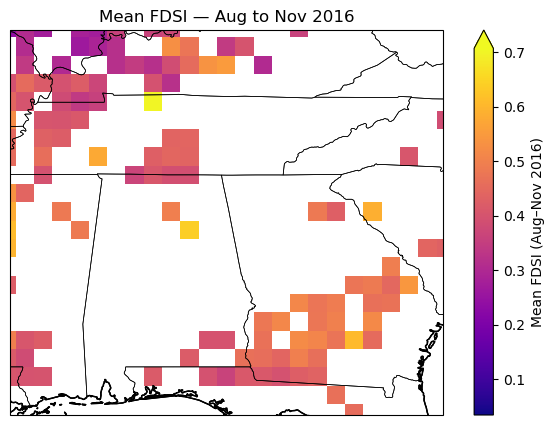

In [36]:
### plot the mean of aug to nov

fdsi_mj_mean = ds['FDSI'].sel(Time=slice('2017-08-01', '2017-11-30')).mean(dim='Time')
fig, ax = plt.subplots(figsize=(8, 5),
                       subplot_kw={'projection': ccrs.PlateCarree()})
im = fdsi_mj_mean.plot(ax=ax, transform=ccrs.PlateCarree(),
                       cmap='plasma', vmax=.707, # blue-red for dry/wet
                       cbar_kwargs={'label': 'Mean FDSI (Aug–Nov 2017)'})
ax.set_extent([-90, -81, 30, 38], crs=ccrs.PlateCarree())  # CONUS
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.coastlines()
ax.coastlines()
ax.set_title('Mean FDSI — Aug to Nov 2017')
plt.show()


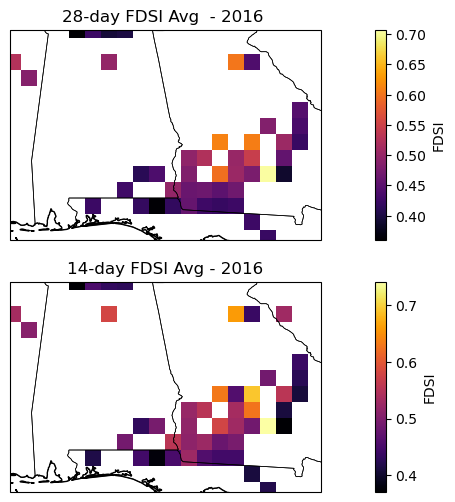

In [37]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


r28 = region_28.sel(Time='2017-11-01')
r14 = region_14.sel(Time='2017-11-01')
# Plot
fig, axes = plt.subplots(2,1, figsize=(14,6),
                       subplot_kw={'projection': ccrs.PlateCarree()})
im = r28.plot(ax=axes[0], transform=ccrs.PlateCarree(),
                       cmap='inferno', vmax=.707,
                       cbar_kwargs={'label': 'FDSI'})
axes[0].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
axes[0].add_feature(cfeature.BORDERS, linewidth=0.8)
axes[0].add_feature(cfeature.STATES, linewidth=0.5)
axes[0].coastlines()
axes[0].set_title('28-day FDSI Avg  - 2017 ')

im2 = r14.plot(ax=axes[1], transform=ccrs.PlateCarree(),
                       cmap='inferno',
                       cbar_kwargs={'label': 'FDSI'})
axes[1].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
axes[1].add_feature(cfeature.BORDERS, linewidth=0.8)
axes[1].add_feature(cfeature.STATES, linewidth=0.5)
axes[1].coastlines()
axes[1].set_title('14-day FDSI Avg - 2017')
plt.show()


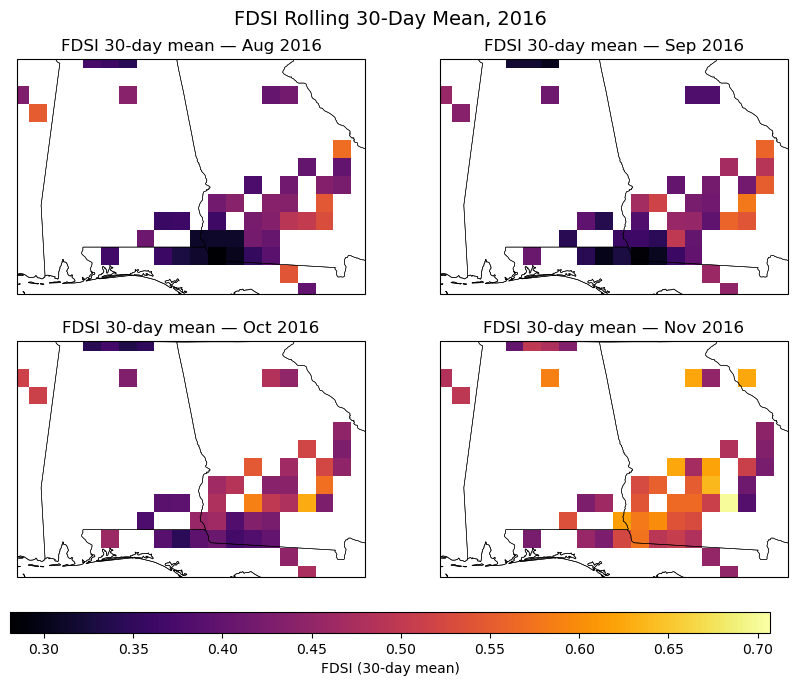

In [38]:

months = ["2017-08", "2017-09", "2017-10", "2017-11"] 
fdsi = region_28.sel(Latitude=slice(lat_max, lat_min), Longitude=slice(lon_min, lon_max))
fdsi30 = fdsi.rolling(Time=30, min_periods=15).mean()

# For each month, take the LAST available day’s 30-day mean (i.e., window ending that month)
maps = []
titles = []
for m in months:
    # Get last day in that month within data
    month_slice = fdsi30.sel(Time=slice(f"{m}-01", pd.Period(m).end_time))
    if month_slice.Time.size == 0:
        continue
    maps.append(month_slice.isel(Time=-1))
    titles.append(pd.Period(m).strftime("%b %Y"))
vmin = xr.concat(maps, dim="month").min().item()
vmax = .707
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(2, 2, figsize=(10, 7), subplot_kw={'projection': proj})
axes = axes.ravel()

im = None
for ax, da, ttl in zip(axes, maps, titles):
    im = da.plot(ax=ax, transform=proj, cmap='inferno', vmin=vmin, vmax=vmax,
                 add_colorbar=False)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.coastlines(linewidth=0.5)
    ax.set_title(f"FDSI 30-day mean — {ttl}")

fig.subplots_adjust(bottom=0.14)  
cax = fig.add_axes([0.12, 0.06, 0.76, 0.03])  

cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.set_label("FDSI (30-day mean)")
fig.suptitle("FDSI Rolling 30-Day Mean, 2017", fontsize=14, y=0.95)
plt.show()



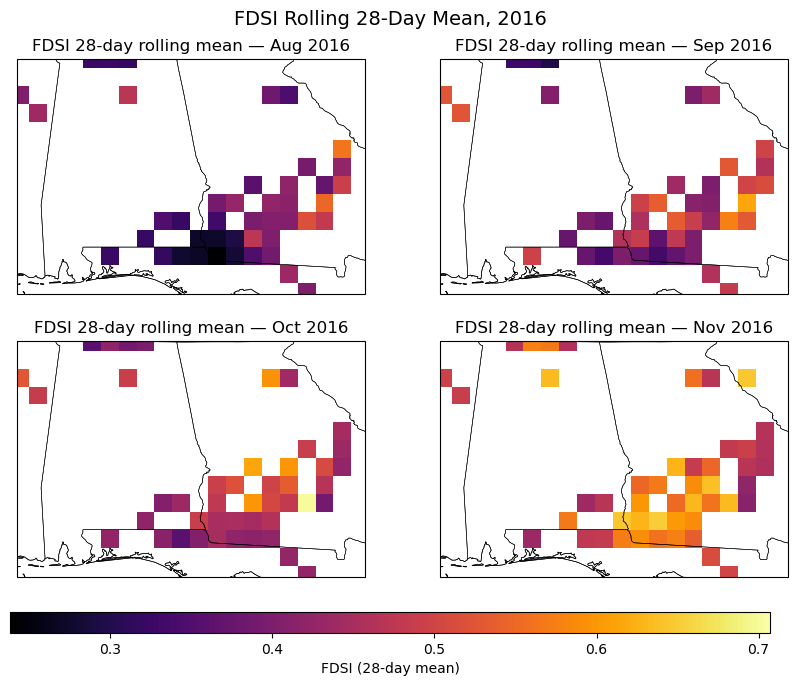

In [39]:

maps = []
titles = []
for m in months:
    month_slice = region_28.sel(Time=slice(f"{m}-01", pd.Period(m).end_time))
    if month_slice.Time.size == 0:
        continue
    maps.append(month_slice.isel(Time=-1))
    titles.append(pd.Period(m).strftime("%b %Y"))

# Common color scale across panels
vmin = xr.concat(maps, dim="month").min().item()
vmax = .707

# Plot 2x2 grid
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(2, 2, figsize=(10, 7), subplot_kw={'projection': proj})
axes = axes.ravel()

im = None
for ax, da, ttl in zip(axes, maps, titles):
    im = da.plot(ax=ax, transform=proj, cmap='inferno', vmin=vmin, vmax=vmax,
                 add_colorbar=False)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.coastlines(linewidth=0.5)
    ax.set_title(f"FDSI 28-day rolling mean — {ttl}")

# Single shared colorbar
# ... your code that builds `im` and the 2×2 axes in `axes` ...

# Reserve space and place a separate colorbar axis
fig.subplots_adjust(bottom=0.14)  # leave room at the bottom
cax = fig.add_axes([0.12, 0.06, 0.76, 0.03])  # [left, bottom, width, height] in figure coords

cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.set_label("FDSI (28-day mean)")
fig.suptitle("FDSI Rolling 28-Day Mean, 2017", fontsize=14, y=0.95)
plt.show()



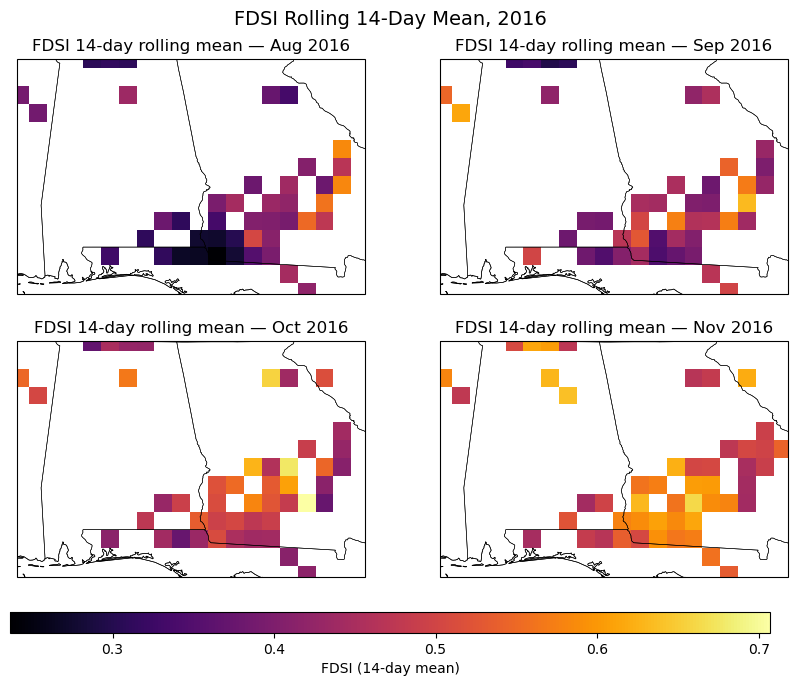

In [41]:
maps = []
titles = []
for m in months:
    # Get last day in that month within data
    month_slice = region_14.sel(Time=slice(f"{m}-01", pd.Period(m).end_time))
    if month_slice.Time.size == 0:
        continue
    maps.append(month_slice.isel(Time=-1))
    titles.append(pd.Period(m).strftime("%b %Y"))

vmin = xr.concat(maps, dim="month").min().item()
vmax = .707
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(2, 2, figsize=(10, 7), subplot_kw={'projection': proj})
axes = axes.ravel()

im = None
for ax, da, ttl in zip(axes, maps, titles):
    im = da.plot(ax=ax, transform=proj, cmap='inferno', vmin=vmin, vmax=vmax,
                 add_colorbar=False)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.coastlines(linewidth=0.5)
    ax.set_title(f"FDSI 14-day rolling mean — {ttl}")

fig.subplots_adjust(bottom=0.14)
cax = fig.add_axes([0.12, 0.06, 0.76, 0.03])

cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.set_label("FDSI (14-day mean)")
fig.suptitle("FDSI Rolling 14-Day Mean, 2017", fontsize=14, y=0.95)
plt.show()



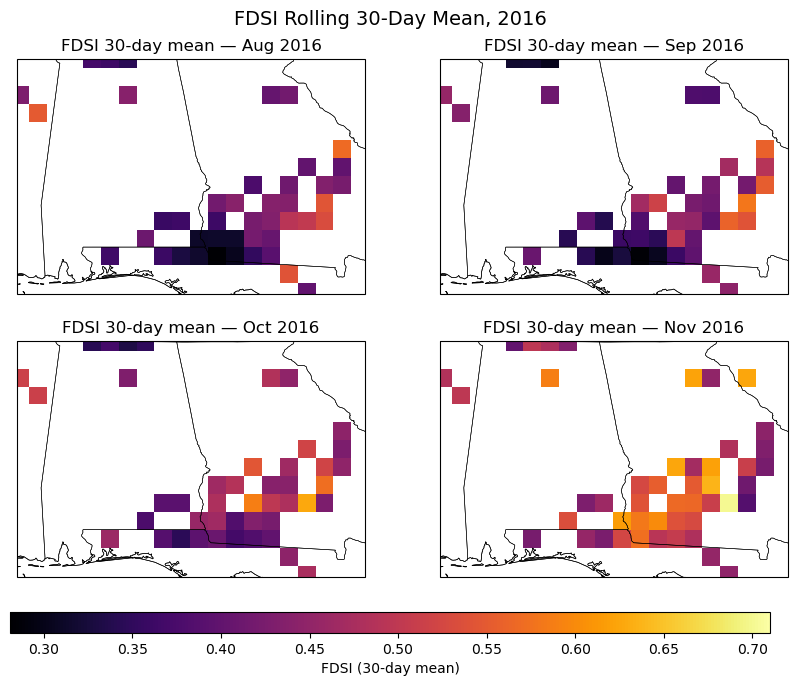

In [42]:

# --- Config ---
months = ["2017-08", "2017-09", "2017-10", "2017-11"]  

fdsi = region_28.sel(Latitude=slice(lat_max, lat_min), Longitude=slice(lon_min, lon_max))

# 30-day rolling mean over time
fdsi30 = fdsi.rolling(Time=30, min_periods=15).mean()

maps = []
titles = []
for m in months:
    month_slice = fdsi30.sel(Time=slice(f"{m}-01", pd.Period(m).end_time))
    if month_slice.Time.size == 0:
        continue
    maps.append(month_slice.isel(Time=-1))
    titles.append(pd.Period(m).strftime("%b %Y"))

vmin = xr.concat(maps, dim="month").min().item()
vmax = .71

# Plot 2x2 grid
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(2, 2, figsize=(10, 7), subplot_kw={'projection': proj})
axes = axes.ravel()

im = None
for ax, da, ttl in zip(axes, maps, titles):
    im = da.plot(ax=ax, transform=proj, cmap='inferno', vmin=vmin, vmax=vmax,
                 add_colorbar=False)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.coastlines(linewidth=0.5)
    ax.set_title(f"FDSI 30-day mean — {ttl}")

# Single shared colorbar
# ... your code that builds `im` and the 2×2 axes in `axes` ...

# Reserve space and place a separate colorbar axis
fig.subplots_adjust(bottom=0.14)  # leave room at the bottom
cax = fig.add_axes([0.12, 0.06, 0.76, 0.03])  # [left, bottom, width, height] in figure coords

cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.set_label("FDSI (30-day mean)")
fig.suptitle("FDSI Rolling 30-Day Mean, 2017", fontsize=14, y=0.95)
plt.show()



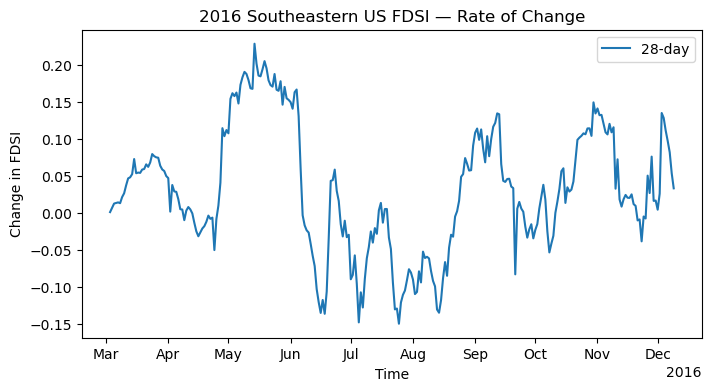

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))
rate_series_28.plot(ax=ax, label='28-day')
ax.set_title("2017 Southeastern US FDSI — Rate of Change")
ax.set_xlabel("Time")
ax.set_ylabel("Change in FDSI")
ax.legend()

plt.show()


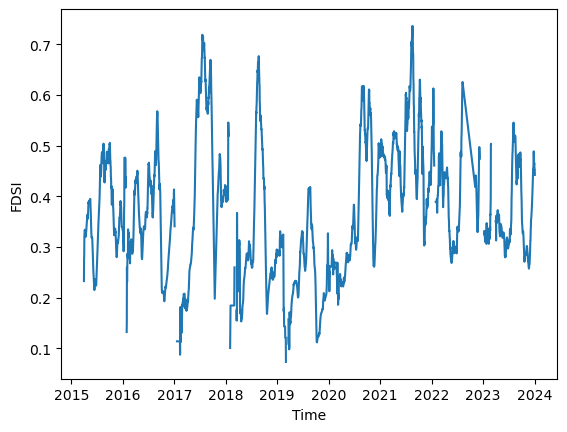

In [10]:
ds = ds.sel(Latitude=slice(lat_max, lat_min), Longitude = slice(lon_min, lon_max))

dst = ds.mean(dim=["Latitude", "Longitude"], skipna=True)

dst['FDSI'].plot()